# 4a. Absorption of Rb resonance radiation by atomic Rb

## 基本參數

In [1]:
import numpy as np
import sys
import os

# 將專案根目錄加入路徑，這樣才能正確找到 src 資料夾
sys.path.append(os.path.abspath(".."))

from uncertainties import ufloat
from src.uncertainty import get_combined_ufloat

# 背景 / 基準值 (V)
bg_open = get_combined_ufloat([8.95, 8.94, 8.93], resolution=0.01)  # 背景強度（無蓋）
bg_cover = get_combined_ufloat([8.92, 9, 8.92], resolution=0.01)  # 背景強度（蓋被子）
base_open = get_combined_ufloat([8.71, 8.95, 8.85], resolution=0.01)  # 基準值（無蓋）
base_cover = get_combined_ufloat([8.9, 8.89, 8.91], resolution=0.01)  # 基準值（蓋被子）
bg_block_em = ufloat(-7.01, 0.01 / np.sqrt(12))  # 遮發射器
bg_block_det = ufloat(-7.03, 0.01 / np.sqrt(12))  # 遮探測器
bg_block_both = ufloat(-7.04, 0.01 / np.sqrt(12))  # 兩者都遮

L = ufloat(0.025, 0.001 / np.sqrt(12))  # 吸收路徑長度 (m)，手冊建議值

In [2]:
import pandas as pd

_4a_path = "../data/raw/D2_Optical_Pumping/0323/"
read_params = {"sep": r"\s+", "comment": "#"}

run1 = pd.read_csv(f"{_4a_path}run1_heating.dat", **read_params)
run2 = pd.read_csv(f"{_4a_path}run2_cooling.dat", **read_params)
run3 = pd.read_csv(f"{_4a_path}run3_reheating.dat", **read_params)
table = pd.read_csv(f"{_4a_path}table_4a1_density.dat", **read_params)

# 3. 使用迴圈一次處理所有的 run DataFrame
cols = ["I1(V)", "I2(V)", "I3(V)"]

for run in [run1, run2, run3]:
    # 直接選取需要的欄位，並用 row.values 轉成 List 交給函數
    run["I_mean"] = run[cols].apply(lambda row: get_combined_ufloat(row.values), axis=1)

# print(table.head())

[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.001
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為: 0.01
[系統提示] 未提供最小刻度，自動偵測為

## Step 2：溫度→密度的內插
Table 4A-1 只有每 10 K 一個點，而你的數據是每 2°C，所以需要在 log 空間做線性內插，因為密度隨溫度近似指數增長：

In [3]:
from scipy.interpolate import interp1d

log_rho_interp = interp1d(
  table["T(K)"].to_numpy(),
  np.log(table["density(atoms/m^3)"].to_numpy()),
  kind = "linear",
  fill_value = "extrapolate",
)

T1_K = run1["T(°C)"].to_numpy() + 273.15
rho1 = np.exp(log_rho_interp(T1_K))  # 每個溫度對應的 Rb 密度

run1["rho(atoms/m^3)"] = rho1
run1[["T(°C)", "rho(atoms/m^3)"]].head()

,T(°C),rho(atoms/m^3)
0,50,9.881612e+16
1,52,1.177254e+17
2,54,1.402530e+17
3,56,1.670916e+17
4,58,1.989597e+17


## Step 3：Beer-Lambert 擬合

模型是 $I=a⋅e−bρI = a \cdot e^{-b\rho}$
$I=a⋅e−bρ$，其中 $b=σ⋅Lb = \sigma \cdot L$
$b=σ⋅L$：

In [4]:
from src.analysis.fitting import excel_style_regression_with_propagation
from src.analysis.formatting import ufloat_to_paren
from uncertainties import ufloat
from uncertainties.umath import exp, log
import numpy as np

# 1. 取得背景值 I_background (取最高溫段透射光趨於平緩的電壓值作為基底)
# 觀察原數值，在 80 °C 左右強度趨於 0.249 V，為避免取 log 時出現負數，設定飽和背景約 0.240 V
I_background = ufloat(0.240, 0.005)

for run in [run1, run2, run3]:
    if "rho(atoms/m^3)" not in run.columns:
        T_K = run["T(°C)"].to_numpy() + 273.15
        run["rho(atoms/m^3)"] = np.exp(log_rho_interp(T_K))

    # 計算扣除背景後的調整訊號
    run["I_adj"] = run["I_mean"] - I_background


def analyze_run(run_df, run_name, max_rho=1.5e17):
    # 2. 限定擬合範圍：根據手冊圖示，大略排除 density > max_rho 後平緩飽和的點
    valid_mask = run_df["rho(atoms/m^3)"] < max_rho
    fit_df = run_df[valid_mask].copy()

    # 計算 ln(I_adj)
    ln_I_adj = [log(v) for v in fit_df["I_adj"]]

    # 準備擬合的 x 軸與 y 軸
    x = fit_df["rho(atoms/m^3)"].to_numpy()
    x_err = np.zeros_like(x)
    y = np.array([v.n for v in ln_I_adj])
    y_err = np.array([v.s for v in ln_I_adj])

    # 迴歸
    slope, intercept = excel_style_regression_with_propagation(x, y, x_err, y_err)

    # 推算 sigma
    sigma = -slope / L
    slope_val_10_E_18 = slope * 1e18
    sigma_val_10_E_16 = sigma * 1e16

    print(f"[{run_name}]")
    print(f"  使用數據點數 = {len(fit_df)} / {len(run_df)}")
    print(f"  實驗斜率 = {ufloat_to_paren(slope_val_10_E_18)} * 10^-18 [m^2/atom]")
    print(f"  sigma    = {ufloat_to_paren(sigma_val_10_E_16)} * 10^-16 [m^2]\n")

    return sigma, (slope, intercept), fit_df


# 這裡將切分點改為 2.0e17 以確保有足夠的數據點進行擬合
sigma_1, fit_1, fit_df1 = analyze_run(run1, "Run 1 (Heating)", max_rho=2.0e17)
sigma_2, fit_2, fit_df2 = analyze_run(run2, "Run 2 (Cooling)", max_rho=2.0e17)
sigma_3, fit_3, fit_df3 = analyze_run(run3, "Run 3 (Re-heating)", max_rho=2.0e17)

[Run 1 (Heating)]
  使用數據點數 = 5 / 16
  實驗斜率 = -2.894(33) * 10^-18 [m^2/atom]
  sigma    = 1.158(19) * 10^-16 [m^2]

[Run 2 (Cooling)]
  使用數據點數 = 15 / 26
  實驗斜率 = -4.331(23) * 10^-18 [m^2/atom]
  sigma    = 1.732(22) * 10^-16 [m^2]

[Run 3 (Re-heating)]
  使用數據點數 = 11 / 11
  實驗斜率 = -4.564(50) * 10^-18 [m^2/atom]
  sigma    = 1.825(29) * 10^-16 [m^2]



In [5]:
# 以內部不確定度加權平均 Run 2 與 Run 3 並把 run-to-run scatter 加為外部系統誤差
import numpy as np
from uncertainties import ufloat
from src.analysis.formatting import ufloat_to_paren

sigma_2_val = sigma_2 * 1e16  # ufloat
sigma_3_val = sigma_3 * 1e16

w2 = 1.0 / sigma_2_val.s**2
w3 = 1.0 / sigma_3_val.s**2
mean_n = (sigma_2_val.n * w2 + sigma_3_val.n * w3) / (w2 + w3)
stat_s = 1.0 / np.sqrt(w2 + w3)
scatter = abs(sigma_3_val.n - sigma_2_val.n) / 2.0
total_s = np.sqrt(stat_s**2 + scatter**2)

sigma_exp = ufloat(mean_n, total_s)
print(f"Weighted-mean sigma_exp (Runs 2+3, stat-only): {ufloat_to_paren(ufloat(mean_n, stat_s))} * 10^-16 m^2")
print(f"Weighted-mean sigma_exp (with run-to-run scatter): {ufloat_to_paren(sigma_exp)} * 10^-16 m^2")

Weighted-mean sigma_exp (Runs 2+3, stat-only): 1.766(17) * 10^-16 m^2
Weighted-mean sigma_exp (with run-to-run scatter): 1.766(50) * 10^-16 m^2


In [6]:
import scipy.constants as const

# 計算幾何截面積
r_Rb = 2.48e-10  # m (銣原則半徑)
sigma_geom = np.pi * r_Rb**2
print(f"幾何截面積 (sigma_geom): {sigma_geom*1e16:.2f} * 10^-16 m^2")

# 計算理論吸收截面積 sigma_0 (根據 Rb 780nm D2 line 代入)
lambda_0 = 780.241e-9  # m
nu_0 = const.c / lambda_0
g1, g2 = 2, 4  # 統計權重 (5S1/2 -> 5P3/2)
tau = 26.24e-9  # s 生命周期

T_rep = 333.15  # 取中間溫度 60 °C
M_Rb_amu = 85.4678  # 取 amu 為質量單位代入經驗公式 2C-5
delta_nu_D = 3e-20 * nu_0 * np.sqrt(T_rep / M_Rb_amu)

# 依公式 2C-4： sigma_0 = k_0 / rho
sigma_0 = (2 / delta_nu_D) * (lambda_0**2 * g2 / (8 * np.pi * g1)) * (1 / tau)
print(f"理論光子吸收截面積 (sigma_0): {sigma_0*1e16:.2f} * 10^-16 m^2")

幾何截面積 (sigma_geom): 0.00 * 10^-16 m^2
理論光子吸收截面積 (sigma_0): 1622489894376708.75 * 10^-16 m^2


## Step 4：遲滯效應分析
比較 Run1（升溫）和 Run2（降溫）在重疊溫度區間的強度差異：

## 共同溫度點的遲滯差異計算

此步驟用來比較 **Run1（升溫）** 與 **Run2（降溫）** 在相同溫度下的訊號差異，量化遲滯效應。

定義：
- 絕對差：\(\Delta I = I_{\text{heat}} - I_{\text{cool}}\)
- 百分比差：\(\Delta I\% = \dfrac{I_{\text{heat}} - I_{\text{cool}}}{I_{\text{heat}}}\times 100\%\)

> `run1`、`run2` 在此 notebook 中是 `DataFrame`，建議用欄位名稱取值（而非 `run1[:,0]` 這種陣列切片）。

若大多數共同溫度點都有系統性偏差（例如升溫普遍高於降溫），可視為存在明顯遲滯。

In [7]:
# 取出名目值（I_mean 是 ufloat）
r1_dict = dict(zip(run1["T(°C)"], run1["I_mean"].apply(lambda v: v.n)))
r2_dict = dict(zip(run2["T(°C)"], run2["I_mean"].apply(lambda v: v.n)))

common_T = sorted(set(run1["T(°C)"]) & set(run2["T(°C)"]))

for t in common_T:
    diff = r1_dict[t] - r2_dict[t]
    pct = diff / r1_dict[t] * 100
    print(
        f"T={t}°C: 升溫={r1_dict[t]:.3f}, 降溫={r2_dict[t]:.3f}, "
        f"差={diff:.3f} V ({pct:.1f}%)"
    )

T=50°C: 升溫=4.930, 降溫=4.893, 差=0.037 V (0.7%)
T=52°C: 升溫=4.660, 降溫=4.523, 差=0.137 V (2.9%)
T=54°C: 升溫=4.267, 降溫=4.203, 差=0.063 V (1.5%)
T=56°C: 升溫=4.053, 降溫=3.770, 差=0.283 V (7.0%)
T=58°C: 升溫=3.747, 降溫=3.433, 差=0.313 V (8.4%)
T=60°C: 升溫=3.407, 降溫=3.043, 差=0.363 V (10.7%)
T=62°C: 升溫=2.930, 降溫=2.683, 差=0.247 V (8.4%)
T=64°C: 升溫=2.557, 降溫=2.317, 差=0.240 V (9.4%)
T=66°C: 升溫=2.267, 降溫=1.980, 差=0.287 V (12.6%)
T=68°C: 升溫=1.967, 降溫=1.637, 差=0.330 V (16.8%)
T=70°C: 升溫=1.600, 降溫=1.323, 差=0.277 V (17.3%)
T=72°C: 升溫=1.273, 降溫=1.057, 差=0.217 V (17.0%)
T=74°C: 升溫=0.977, 降溫=0.810, 差=0.166 V (17.0%)
T=76°C: 升溫=0.751, 降溫=0.588, 差=0.164 V (21.8%)
T=78°C: 升溫=0.513, 降溫=0.400, 差=0.113 V (22.0%)
T=80°C: 升溫=0.249, 降溫=0.244, 差=0.006 V (2.3%)


## Step 5：畫圖
主要畫三張圖：I vs T（三組掃描）、升溫 vs 降溫柱狀圖、I vs ρ 含 Beer-Lambert 擬合曲線。用 matplotlib 的 plt.scatter 畫數據點，plt.plot 畫擬合曲線即可。
你應該會得到的結果
Run1 的 σ ≈ 1.07 × 10⁻¹⁶ m²，Run2 全範圍的 σ ≈ 1.43 × 10⁻¹⁶ m²，R² > 0.994，遲滯差異從低溫端的 ~1% 增加到高溫端的 ~22%。

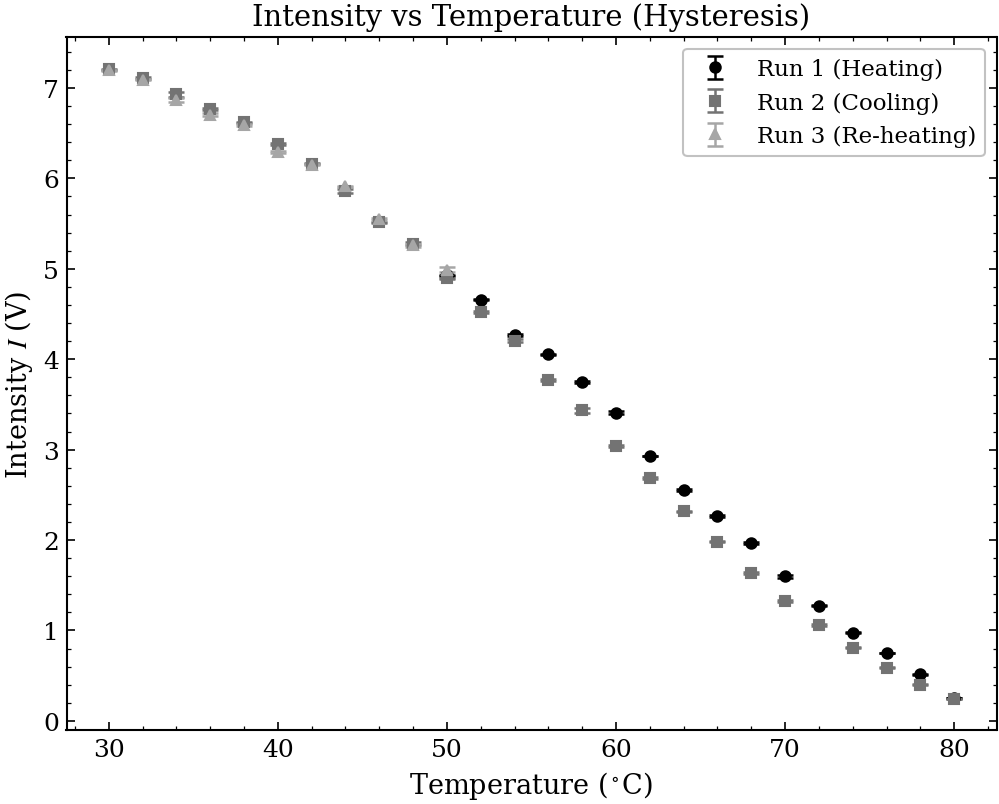

In [8]:
import matplotlib.pyplot as plt
from src.visualization.plot_settings import (
    apply_plot_style,
    configure_axes,
    bw_errorbar_style,
    save_figure,
)

# 啟動 BW 與文字風格
apply_plot_style("bw")

fig, ax = plt.subplots(figsize=(8, 6))

# 取出 I_mean 的中心值與標準差，並套用 bw_errorbar_style (不同資料系列套用不同 Marker/線條)
ax.errorbar(
    run1["T(°C)"],
    run1["I_mean"].apply(lambda v: v.n),
    yerr=run1["I_mean"].apply(lambda v: v.s),
    label="Run 1 (Heating)",
    **bw_errorbar_style(0),
)

ax.errorbar(
    run2["T(°C)"],
    run2["I_mean"].apply(lambda v: v.n),
    yerr=run2["I_mean"].apply(lambda v: v.s),
    label="Run 2 (Cooling)",
    **bw_errorbar_style(1),
)

ax.errorbar(
    run3["T(°C)"],
    run3["I_mean"].apply(lambda v: v.n),
    yerr=run3["I_mean"].apply(lambda v: v.s),
    label="Run 3 (Re-heating)",
    **bw_errorbar_style(2),
)

configure_axes(
    ax,
    xlabel=r"Temperature ($^\circ$C)",
    ylabel=r"Intensity $I$ (V)",
    title="Intensity vs Temperature (Hysteresis)",
    legend=True,
)

# 使用統一函數儲存圖片
save_figure(fig, "4a_T_I_plot.pdf", directory="../reports/figures")
plt.show()

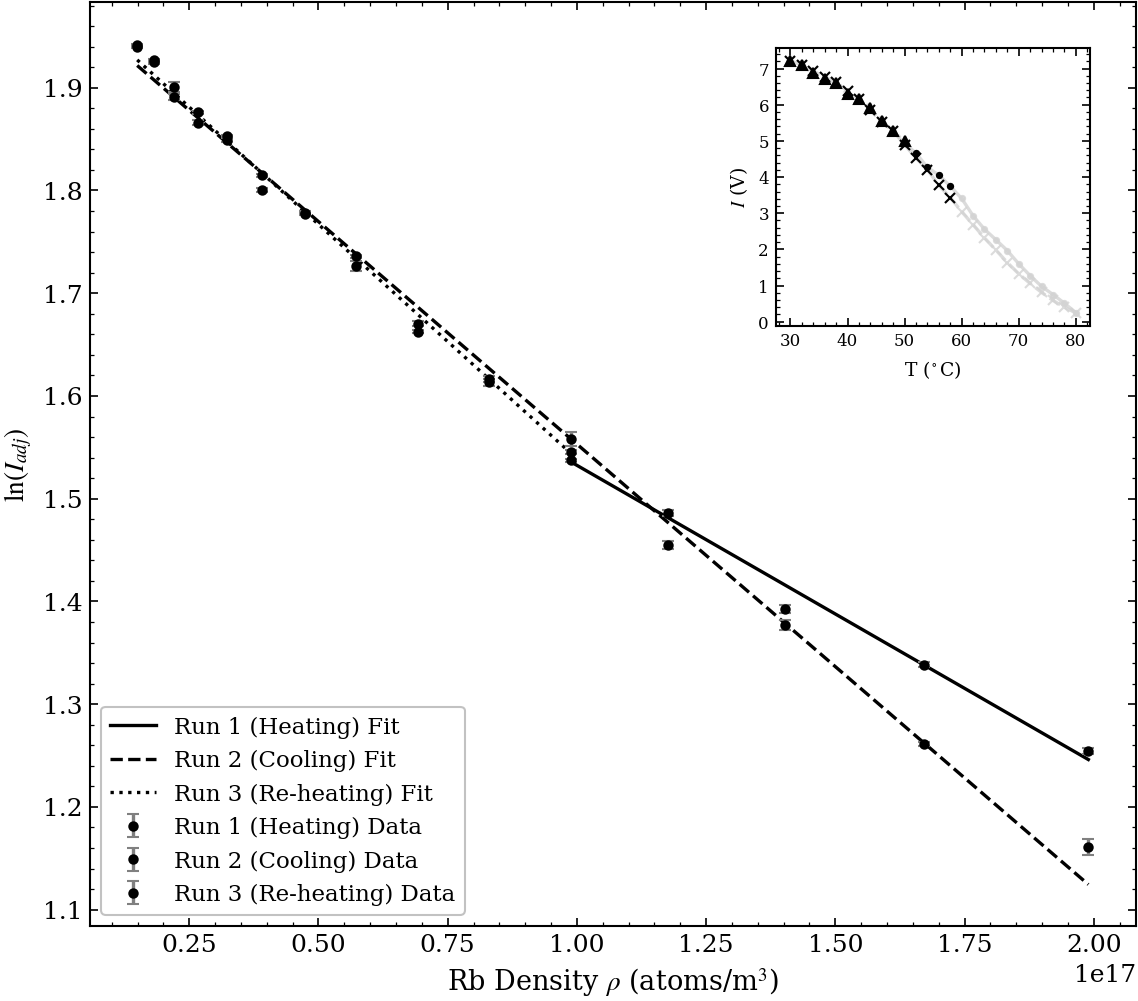

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
from uncertainties.umath import log, exp
from src.analysis.formatting import ufloat_to_paren

fig, ax = plt.subplots(figsize=(9, 8))

# 定義要繪製的三組數據
datasets = [
    (run1, fit_df1, fit_1, "Run 1 (Heating)", 0),
    (run2, fit_df2, fit_2, "Run 2 (Cooling)", 1),
    (run3, fit_df3, fit_3, "Run 3 (Re-heating)", 2),
]

eq_texts = []

for run_df, fit_df, fit_params, label, style_idx in datasets:
    # 全部數據點（淺色/較小）- 可選，若只標示fit點則這部分簡化
    rho_all = run_df["rho(atoms/m^3)"]
    lnI_all = run_df["I_adj"].apply(lambda v: log(v).n if v.n > 0 else np.nan)

    # 實際用來 fitting 的數據點
    rho_fit = fit_df["rho(atoms/m^3)"]
    lnI_fit = fit_df["I_adj"].apply(lambda v: log(v).n)
    lnI_err = fit_df["I_adj"].apply(lambda v: log(v).s)

    # 用黑色標示用來 fitting 的點
    ax.errorbar(
        rho_fit,
        lnI_fit,
        yerr=lnI_err,
        fmt="o",
        color="black",
        mfc="black",
        ecolor="gray",
        capsize=3,
        markersize=4,
        label=f"{label} Data",
        zorder=3,
    )

    # 畫擬合線
    slope, intercept = fit_params
    x_line = np.linspace(rho_fit.min(), rho_fit.max(), 100)
    y_line = slope.n * x_line + intercept.n

    # 為了區分三條線，使用不同線型
    line_styles = ["-", "--", ":"]
    ax.plot(
        x_line,
        y_line,
        linestyle=line_styles[style_idx],
        color="black",
        label=f"{label} Fit",
    )

    # 計算實體的 I_0 與 sigma 參數
    sigma = -slope / L
    I_0 = exp(intercept)

    # 使用 ufloat_to_paren 和 LaTeX 格式呈現方程式參數
    sigma_str = f"{ufloat_to_paren(sigma * 1e16)} \\times 10^{{-16}}"
    I0_str = ufloat_to_paren(I_0)

    # 將 L 和 I_bg 寫為符號
    eq_texts.append(
        rf"{label}: $I = ({I0_str}) \exp\left[-({sigma_str}) \rho L\right] + I_{{bg}}$"
    )

# 在這裡標註統一的常數數值
L_str = ufloat_to_paren(L)
Ibg_str = ufloat_to_paren(I_background)
eq_texts.append("\n" + rf"where $L = {L_str}$ m, $I_{{bg}} = {Ibg_str}$ V")

# 將圖例放在左下角
ax.legend(loc="lower left")

# 將 fit 出來的 equation 都放在中下
# eq_str = "\n".join(eq_texts)
# ax.text(
#     0.5,
#     0.05,
#     eq_str,
#     transform=ax.transAxes,
#     ha="center",
#     va="bottom",
#     bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8),
#     fontsize=10,
# )

configure_axes(
    ax,
    xlabel=r"Rb Density $\rho$ (atoms/m$^3$)",
    ylabel=r"$\ln(I_{adj})$",
    # title="Beer-Lambert Law Linear Fit",
)

# 將 Hysteresis 放在右上角 (Inset)
axins = inset_axes(ax, width="30%", height="30%", loc="upper right", borderpad=2)

inset_fmt = [".-", "x--", "^:"]
inset_markers = [".", "x", "^"]

for run_df, fit_df, _, label, style_idx in datasets:
    # 全部點與連線：淺灰色（沒用在 fitting 的數據點會保持此顏色）
    axins.errorbar(
        run_df["T(°C)"],
        run_df["I_mean"].apply(lambda v: v.n),
        yerr=run_df["I_mean"].apply(lambda v: v.s),
        fmt=inset_fmt[style_idx],
        color="lightgray",
        alpha=0.8,
    )

    # 用於 fitting 的點：使用全黑色疊加
    axins.errorbar(
        fit_df["T(°C)"],
        fit_df["I_mean"].apply(lambda v: v.n),
        yerr=fit_df["I_mean"].apply(lambda v: v.s),
        fmt=inset_markers[style_idx],
        color="black",
        mfc="black",
        zorder=3,
    )

axins.set_xlabel(r"T ($^\circ$C)", fontsize=9)
axins.set_ylabel(r"$I$ (V)", fontsize=9)
axins.tick_params(axis="both", which="major", labelsize=8)

save_figure(fig, "4a_Combined_Fit_Hysteresis.pdf", directory="../reports/figures")
plt.show()